## Building Machine Learning Pipelines: Data Analysis Phase
In this and the upcoming videos we will focus on creating Machine Learning Pipelines considering all the life cycle of a Data Science Projects. This will be important for professionals who have not worked with huge dataset.

Project Name: House Prices: Advanced Regression Techniques
The main aim of this project is to make perfect data set
Dataset to downloaded from the below link
https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

start with import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### pd.set_option("display.max_column",None) which is used to display all columns without  showing like .... between columns

In [2]:
pd.set_option("display.max_column",None)

In [3]:
df=pd.read_csv("train.csv")

In [4]:
df.shape

(1460, 81)

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## data analysis

1. missing Values
2. all The Numerical Variables
3. Distribution of the Numerical Variables
4. categorical Variables
5. Cardinality of Categorical Variables
6. Outliers
7. Relationship between independent and dependent feature(SalePrice)

## **missing values analysis**

In [6]:
features_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>1]

In [7]:
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,2),"% missing value")

LotFrontage 17.74 % missing value
Alley 93.77 % missing value
MasVnrType 59.73 % missing value
MasVnrArea 0.55 % missing value
BsmtQual 2.53 % missing value
BsmtCond 2.53 % missing value
BsmtExposure 2.6 % missing value
BsmtFinType1 2.53 % missing value
BsmtFinType2 2.6 % missing value
FireplaceQu 47.26 % missing value
GarageType 5.55 % missing value
GarageYrBlt 5.55 % missing value
GarageFinish 5.55 % missing value
GarageQual 5.55 % missing value
GarageCond 5.55 % missing value
PoolQC 99.52 % missing value
Fence 80.75 % missing value
MiscFeature 96.3 % missing value


#### find relationship between missing value and sales price

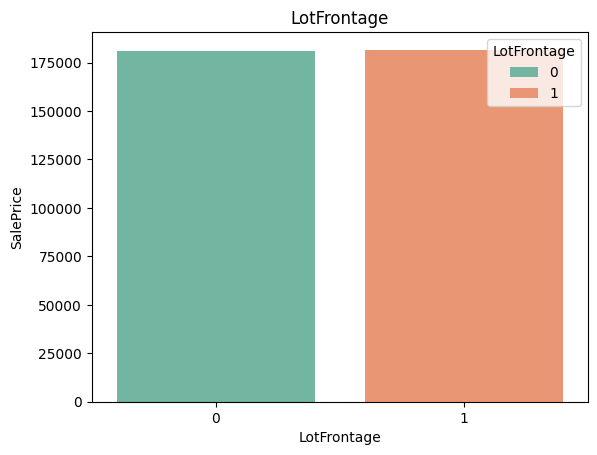

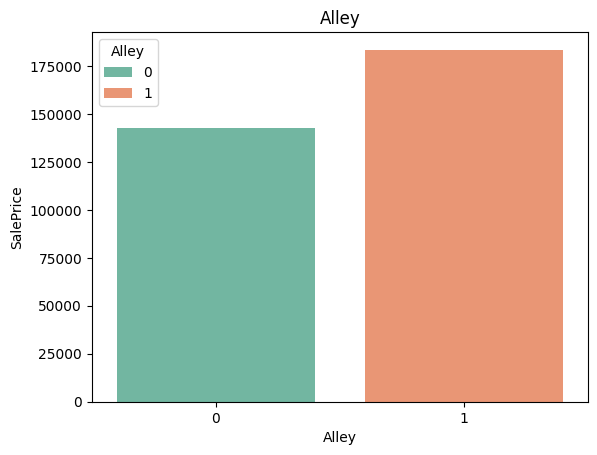

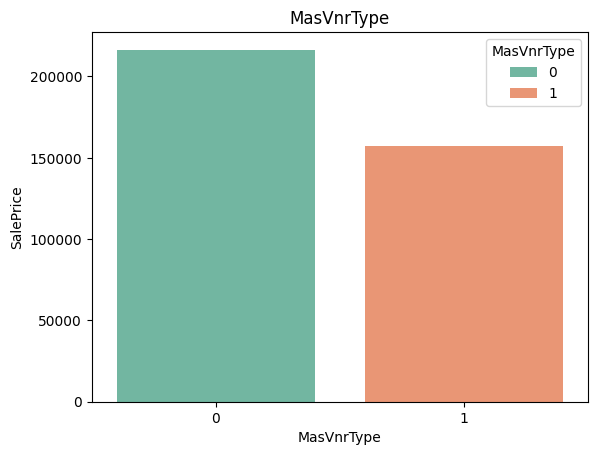

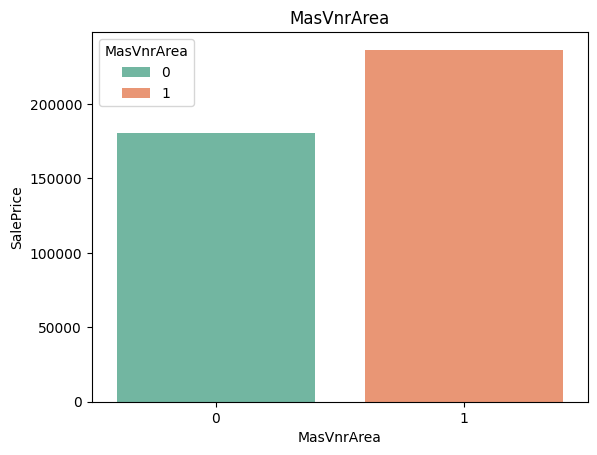

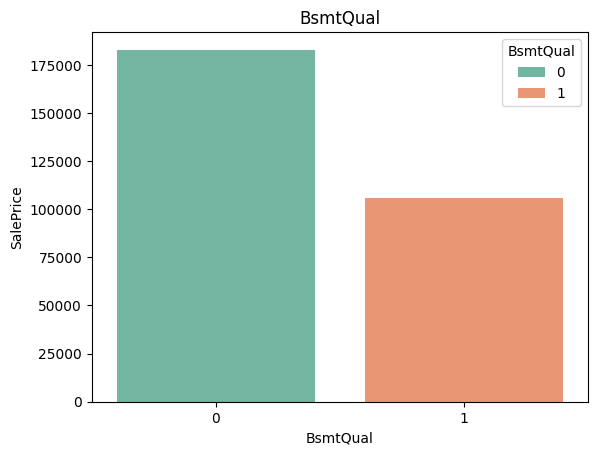

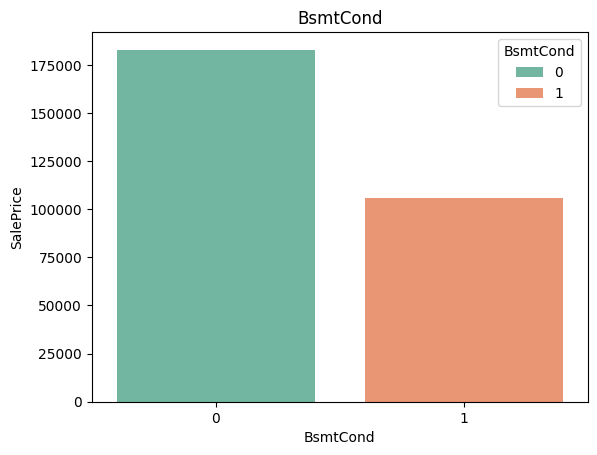

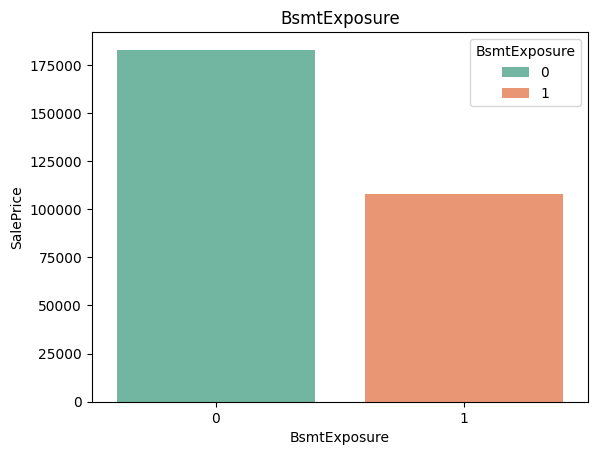

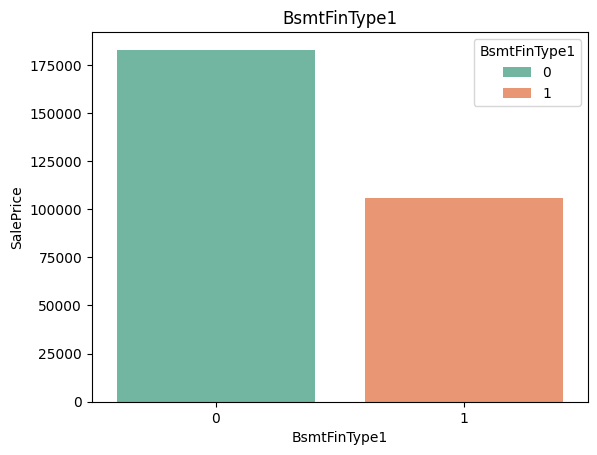

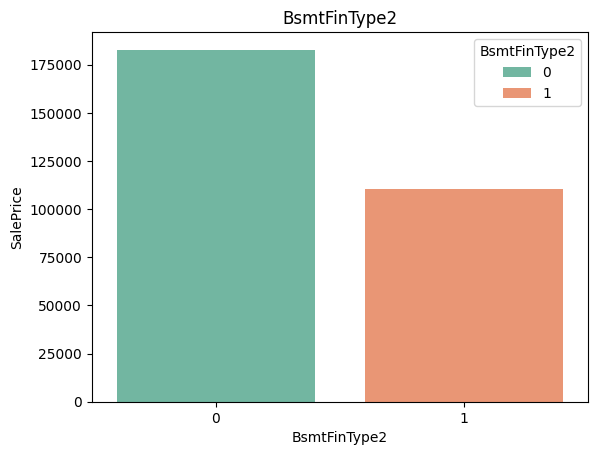

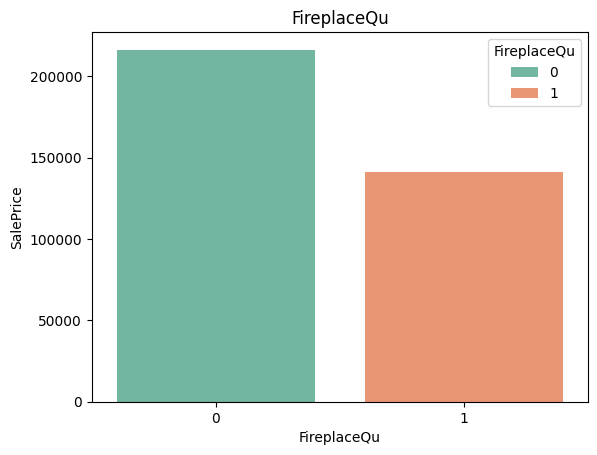

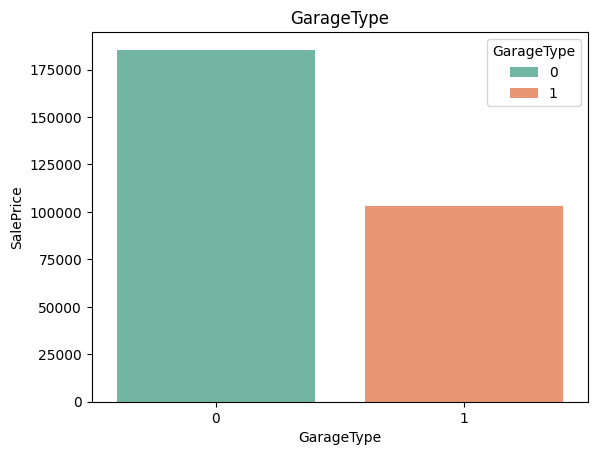

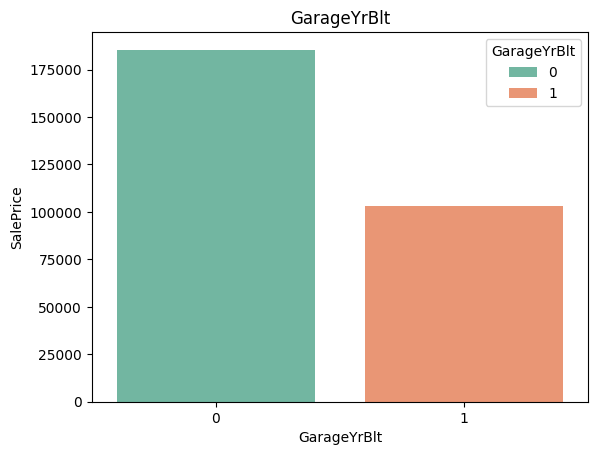

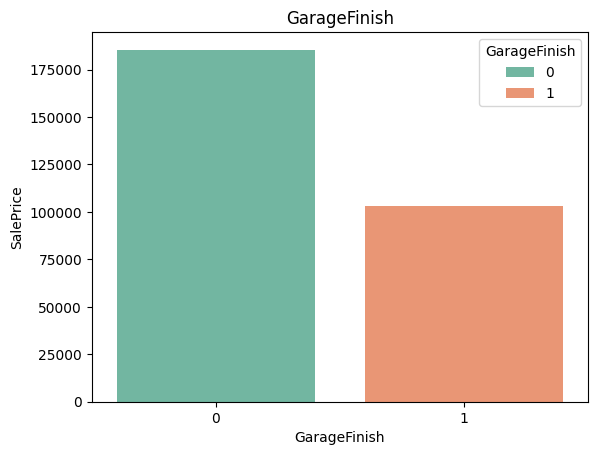

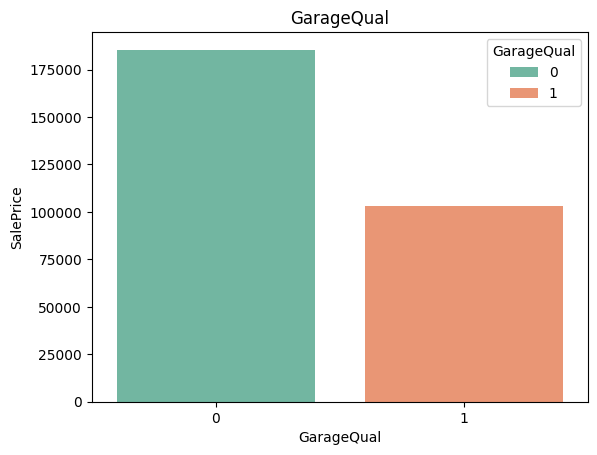

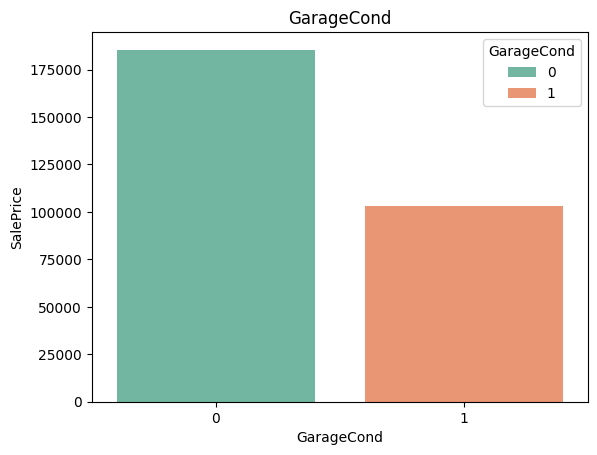

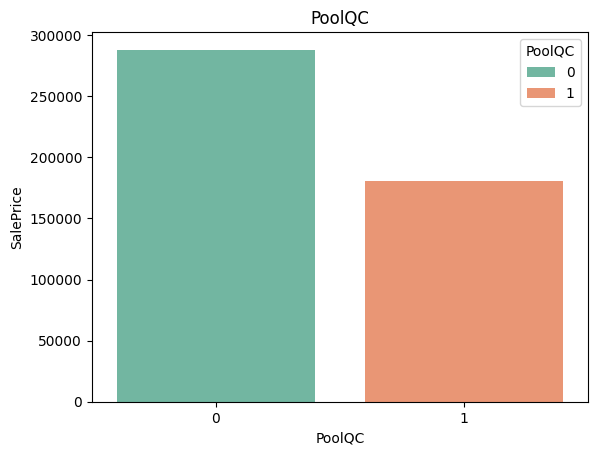

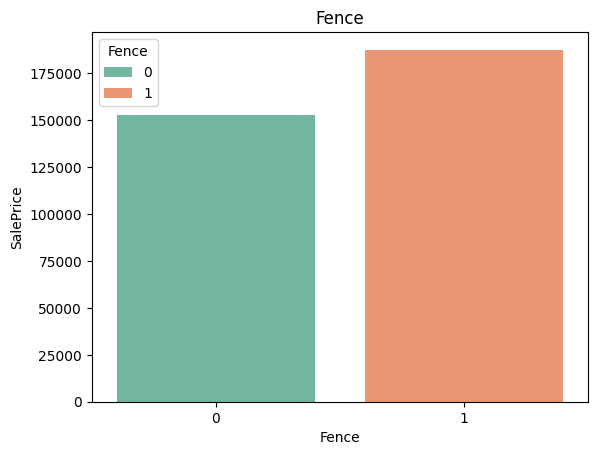

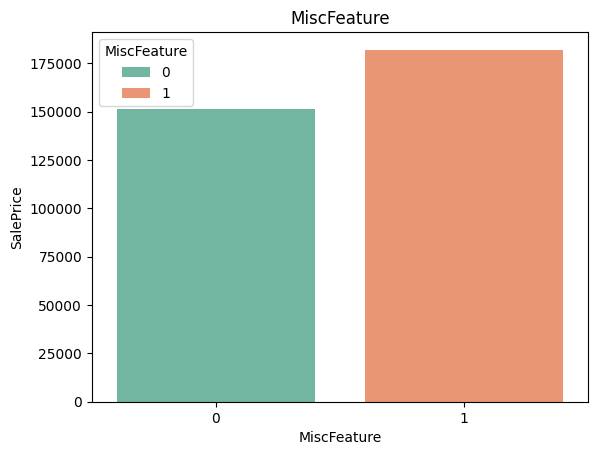

In [8]:
for feature in features_with_na:
    data=df.copy()
    data[feature]=np.where(data[feature].isnull(),1,0)
    group=data.groupby(feature)["SalePrice"].mean().reset_index()
    sns.barplot(x=feature,y="SalePrice",data=group,palette="Set2",hue=feature)
    plt.title(feature)
    plt.show()

## information from above plot
most of missing values in a features are less mean of sales price than the non missing values in the features

from dataset some features like "Id" is not required

In [9]:
df=df.drop(columns=["Id"])

 ## **numerical variables**

In [10]:
numerical_col=[feature for feature in df.columns if df[feature].dtypes!="O"]
len(numerical_col)

37

## here is 37 columns are numerical

### separate year columns 

In [11]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [12]:
year_columns=[feature for feature in numerical_col if "Yr" in feature or "Year" in feature]
df[year_columns]

,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold
0,2003,2003,2003.0,2008
1,1976,1976,1976.0,2007
2,2001,2002,2001.0,2008
3,1915,1970,1998.0,2006
4,2000,2000,2000.0,2008
...,...,...,...,...
1455,1999,2000,1999.0,2007
1456,1978,1988,1978.0,2010
1457,1941,2006,1941.0,2010
1458,1950,1996,1950.0,2010


## we have four year columns

Text(0.5, 1.0, 'house price vs year sold')

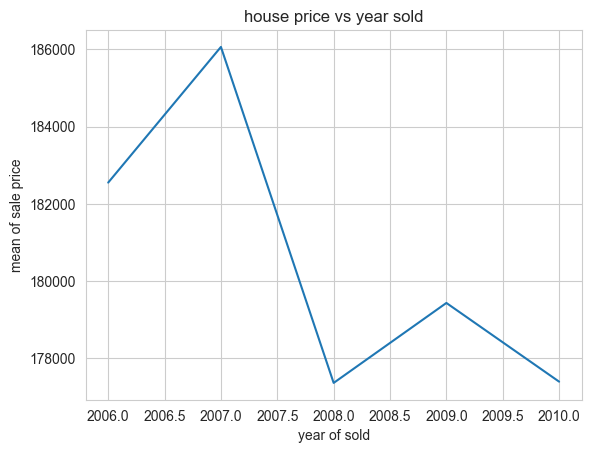

In [13]:
sns.set_style("whitegrid")
df.groupby("YrSold")["SalePrice"].mean().plot()
plt.xlabel("year of sold")
plt.ylabel("mean of sale price")
plt.title("house price vs year sold")

#### now, we got information of year by year price of house price is decreasing 

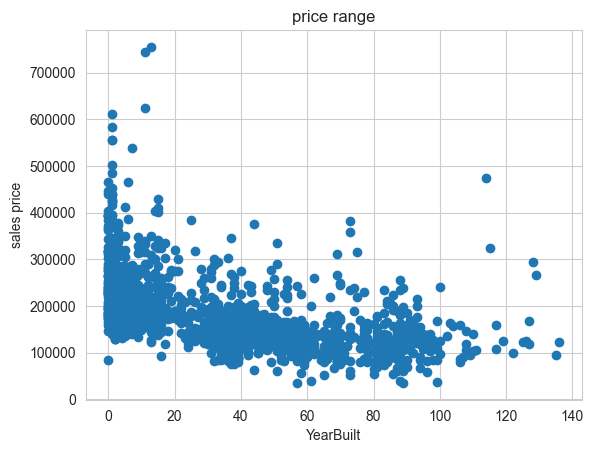

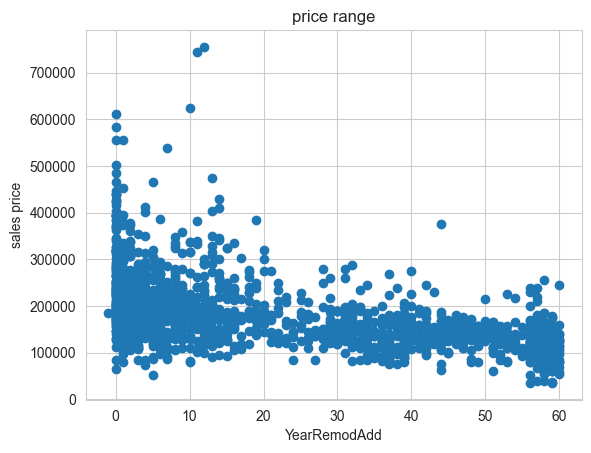

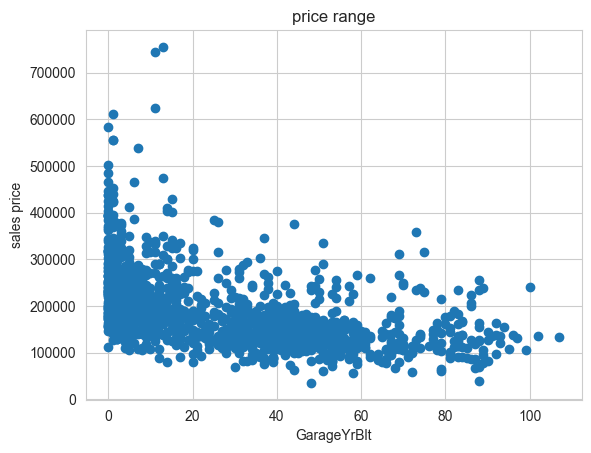

In [14]:
for feature in year_columns:
    if feature!="YrSold":
        data=df.copy()
        data[feature]=data["YrSold"]-data[feature]
        plt.scatter(data[feature],data["SalePrice"])
        plt.title("price range")
        plt.xlabel(feature)
        plt.ylabel("sales price")
        plt.show()

#### new builded house ,latest remodified house, recent gaurage built year is goes to higher selling price

In [15]:
discrete=[feature for feature in numerical_col if len(df[feature].unique())<25 and feature not in year_columns+["Id"]]
len(discrete)

17

## we have 17 discrete column 

In [16]:
df[discrete].head()

,MSSubClass,OverallQual,OverallCond,LowQualFinSF,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,3SsnPorch,PoolArea,MiscVal,MoSold
0,60,7,5,0,1,0,2,1,3,1,8,0,2,0,0,0,2
1,20,6,8,0,0,1,2,0,3,1,6,1,2,0,0,0,5
2,60,7,5,0,1,0,2,1,3,1,6,1,2,0,0,0,9
3,70,7,5,0,1,0,1,0,3,1,7,1,3,0,0,0,2
4,60,8,5,0,1,0,2,1,4,1,9,1,3,0,0,0,12


## **discrete variables**

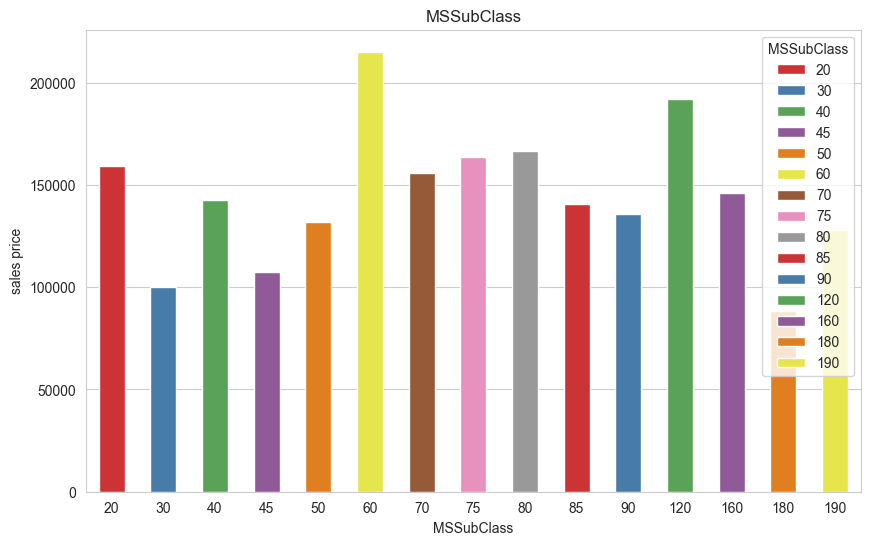

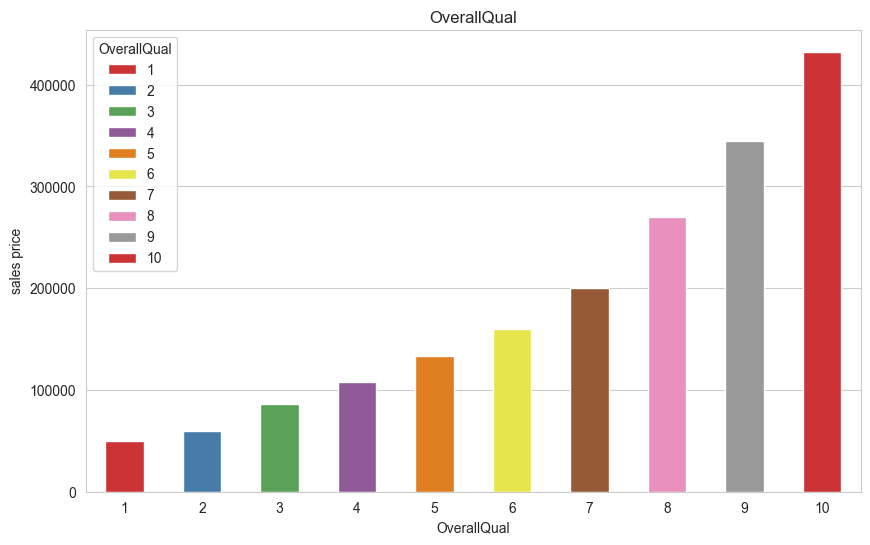

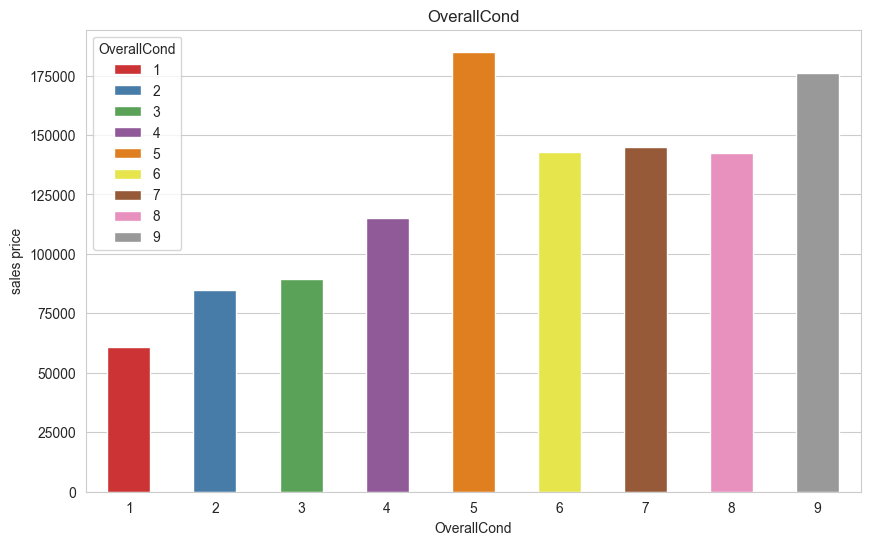

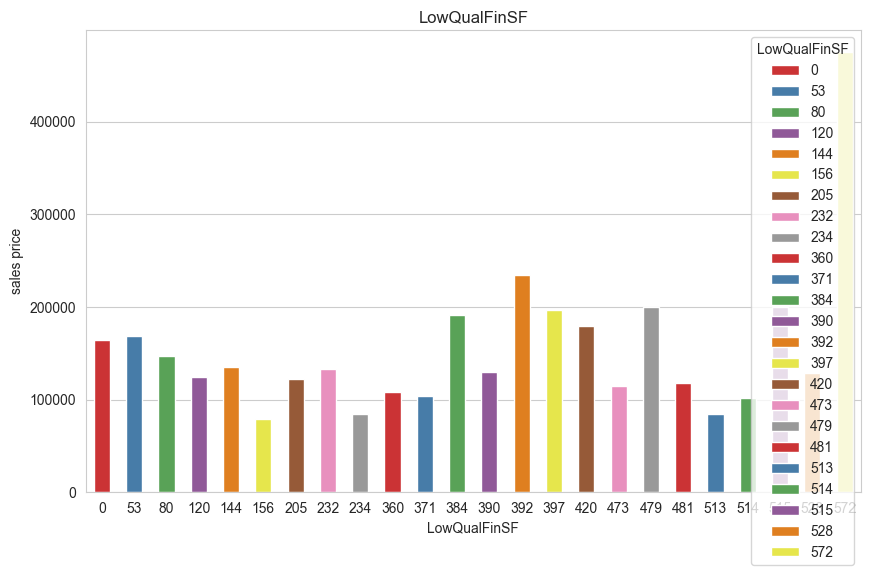

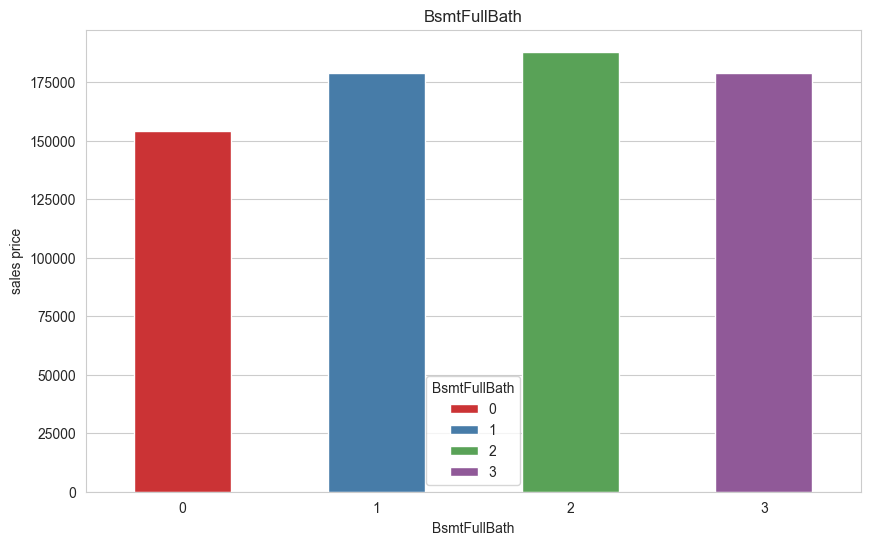

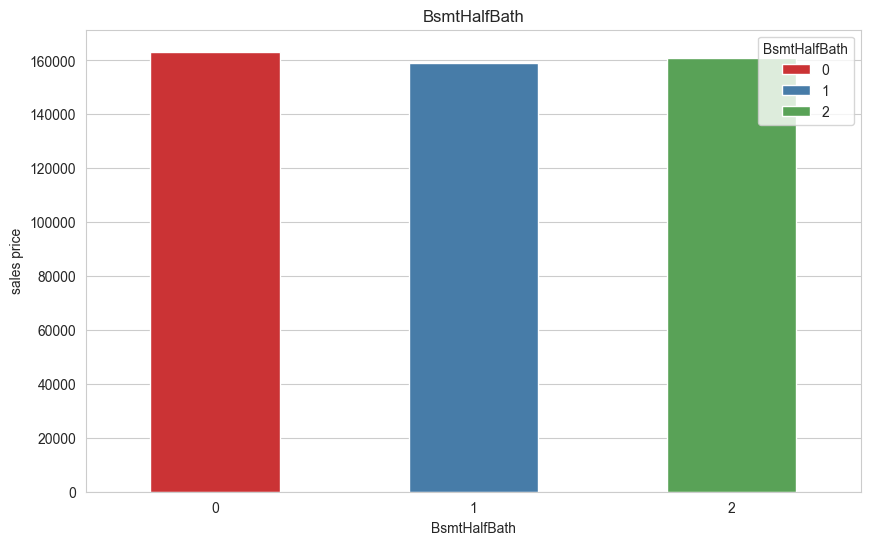

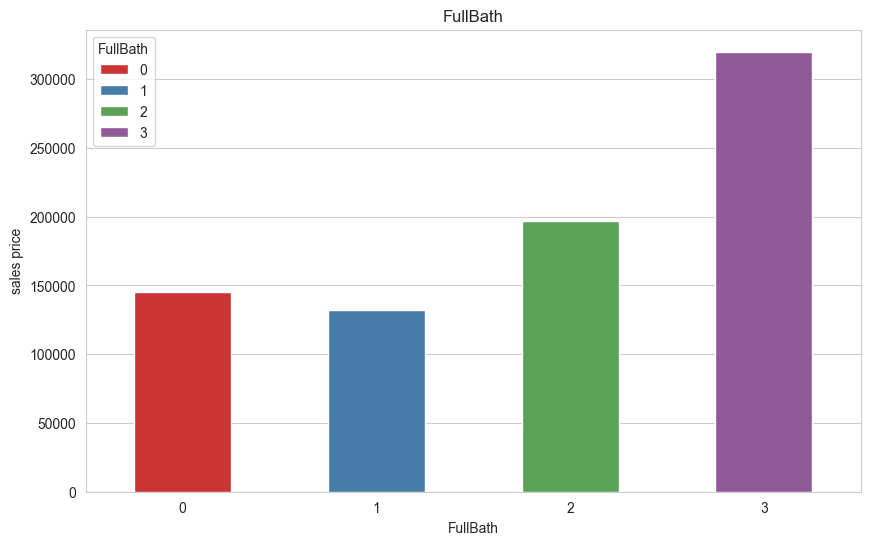

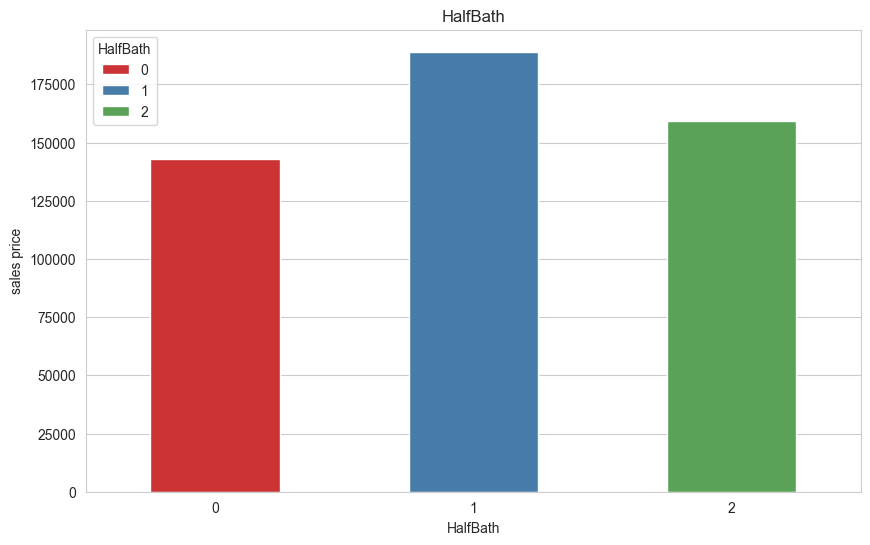

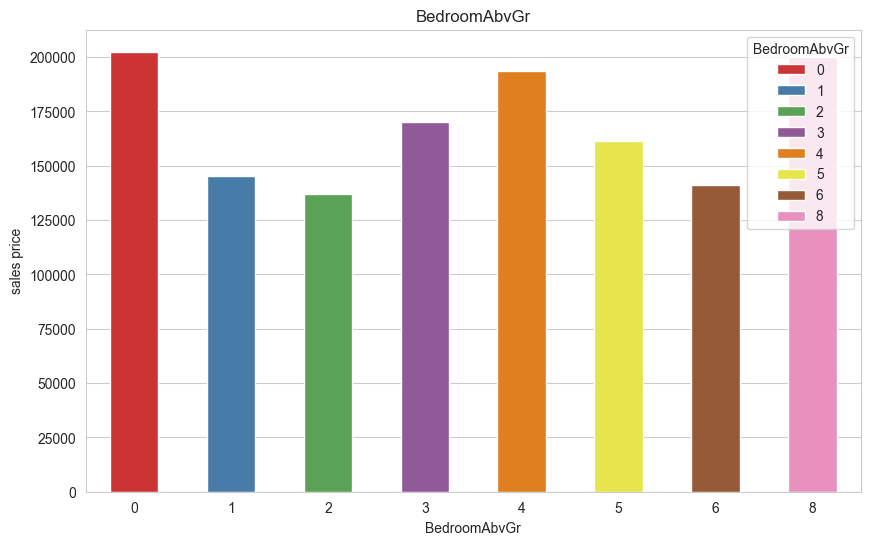

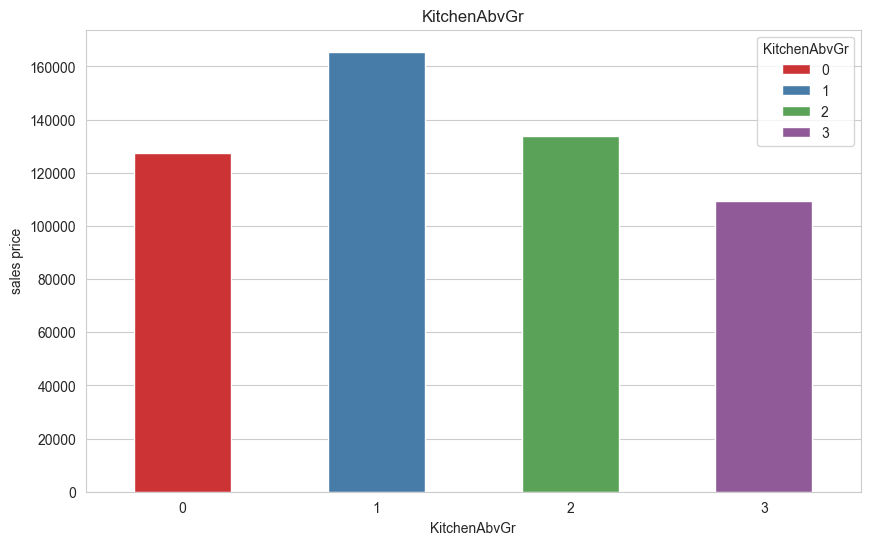

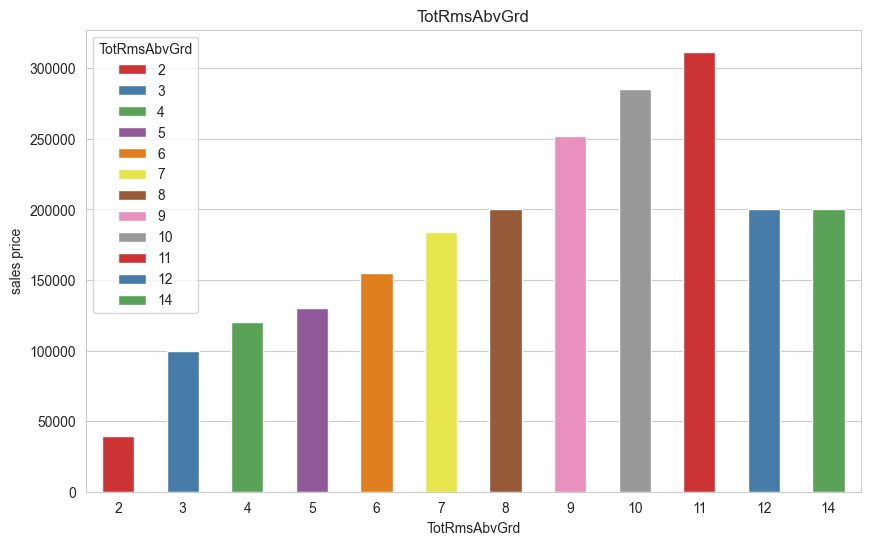

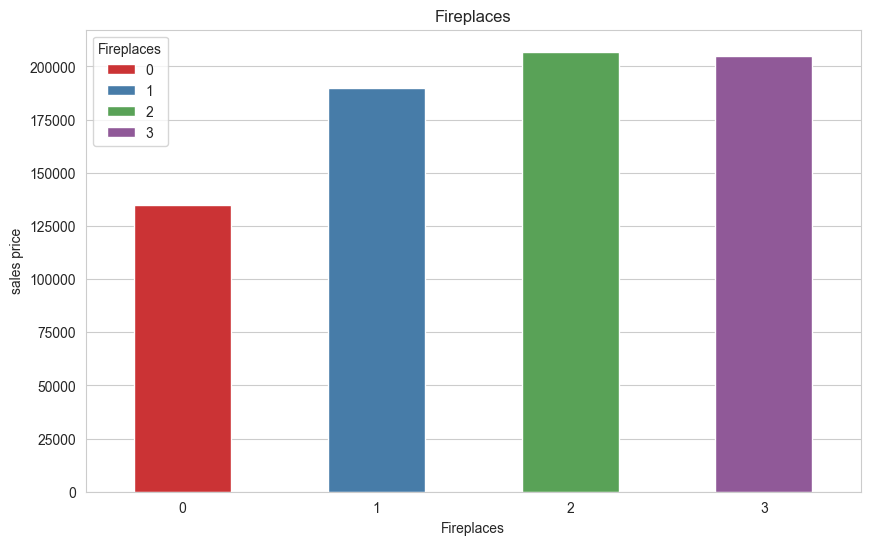

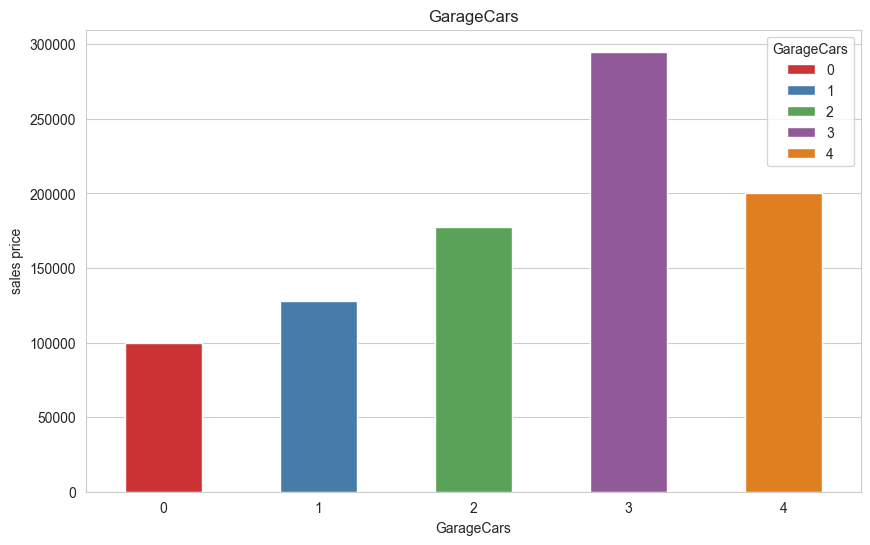

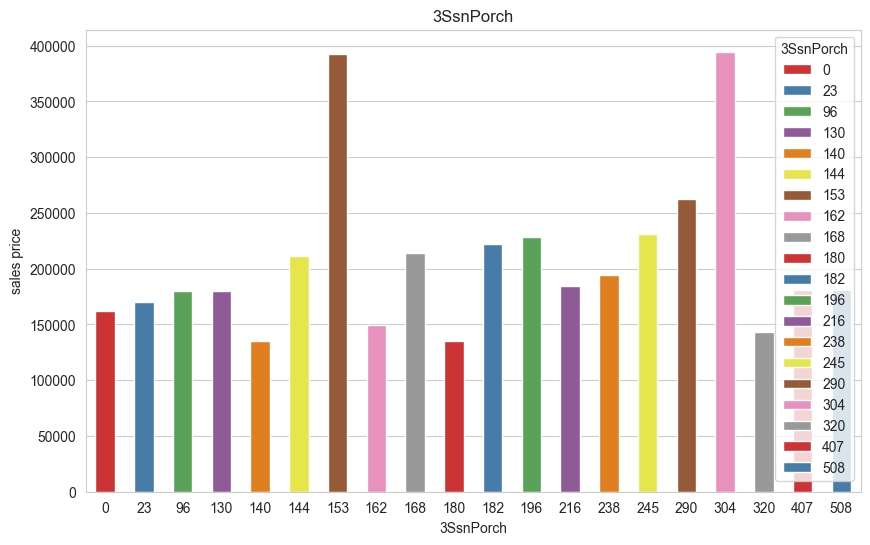

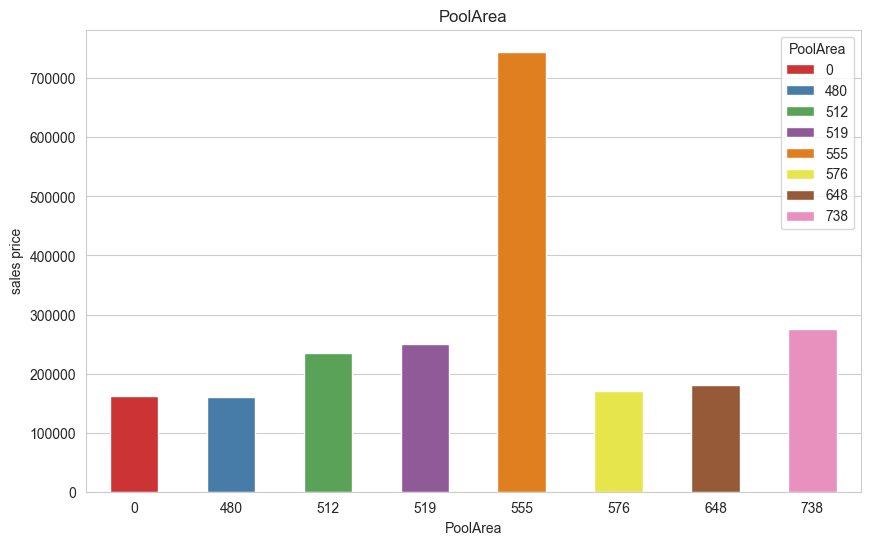

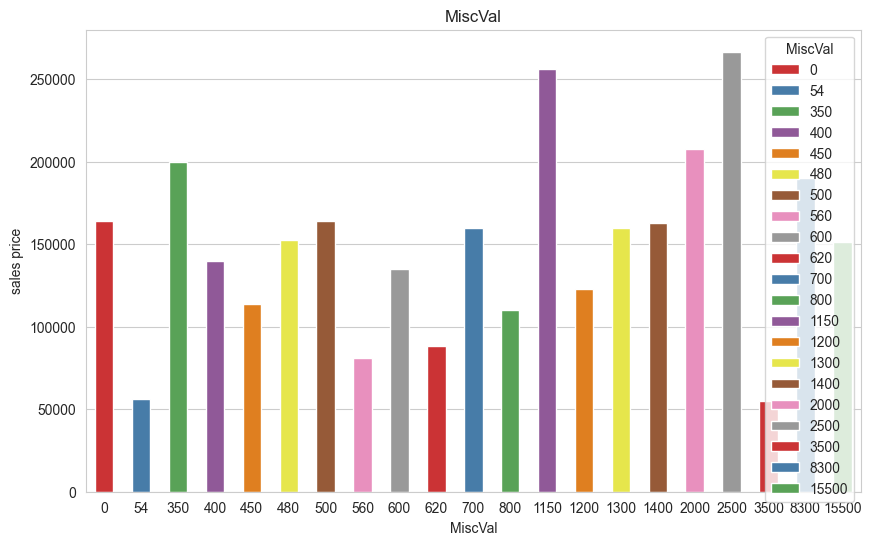

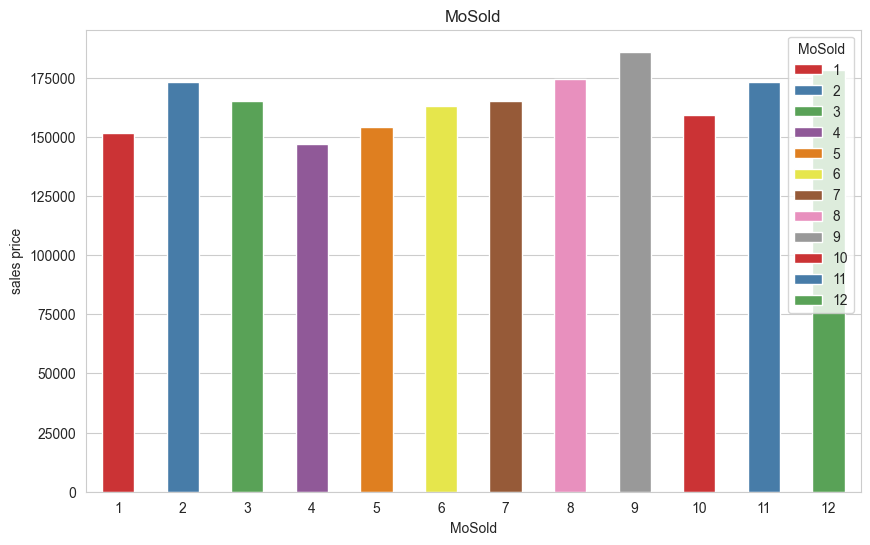

In [17]:
for feature in discrete:
    data=df.copy()
    grouped=data.groupby(feature)["SalePrice"].median().reset_index()
    plt.figure(figsize=(10,6))
    sns.barplot(x=feature,y="SalePrice",data=grouped,palette="Set1",estimator='median',hue=feature,width=0.5)
    plt.xlabel(feature)
    plt.ylabel("sales price")
    plt.title(feature)
    plt.show()

#### here we got some information by relationship between discrete and sale price 
1. overallqual
2. overallcond
3. gaurage cars
4. totrmsadvgrb
5. misval
6. fullbath

are getting increasing with price gradually

## **continuous variables**

In [18]:
continuous=[feature for feature in numerical_col if feature not in discrete+year_columns+["id"]]
len(continuous)

16

## here we have 16 continuous features

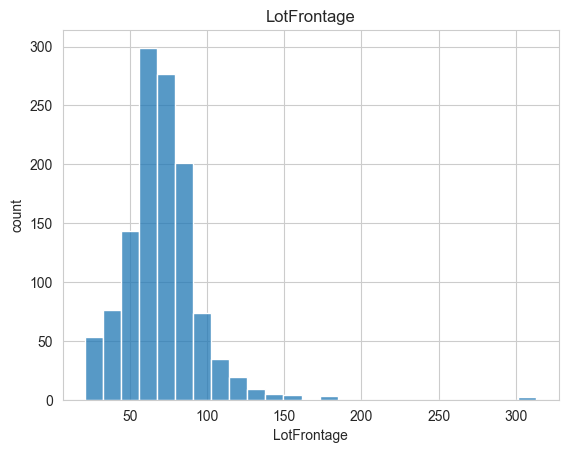

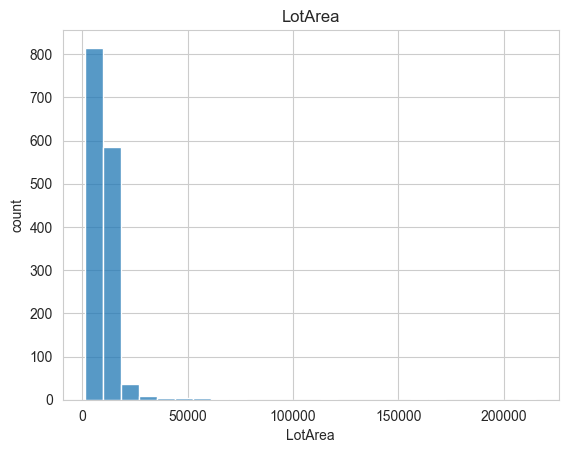

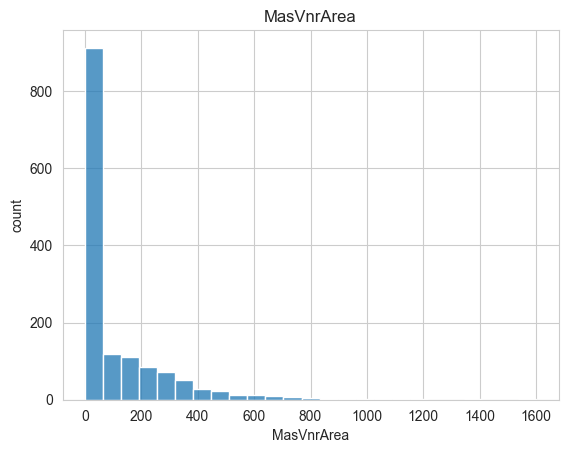

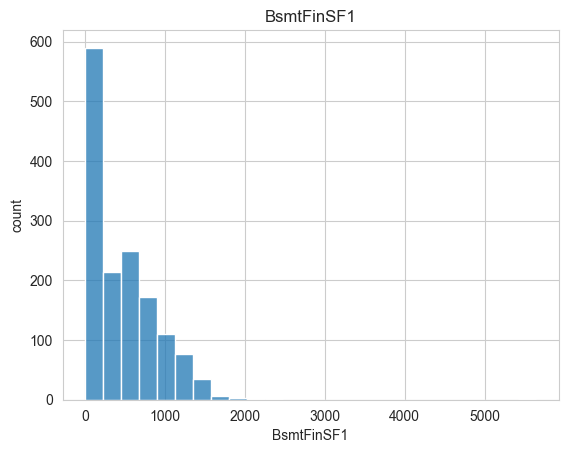

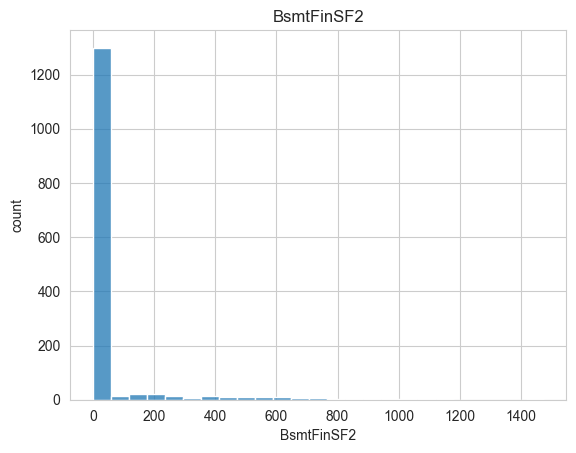

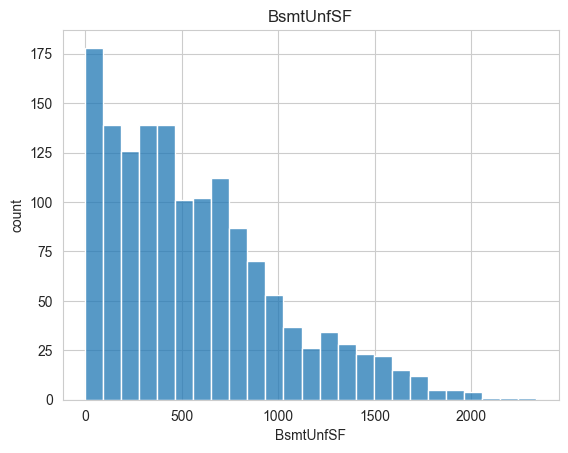

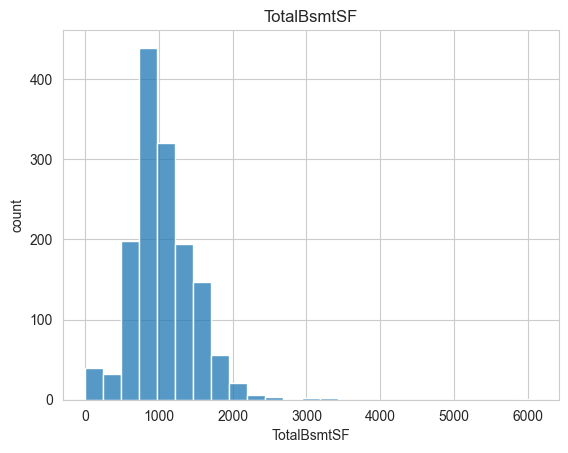

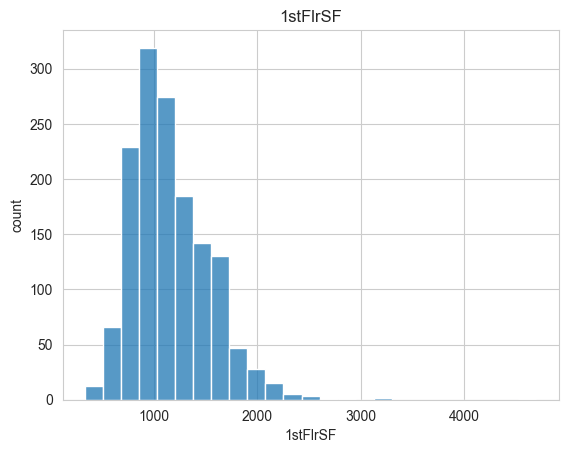

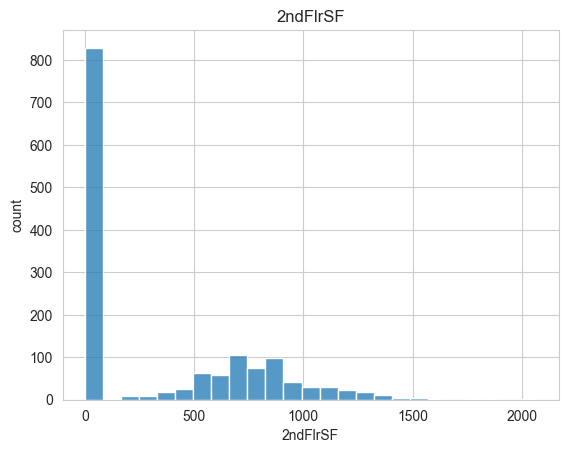

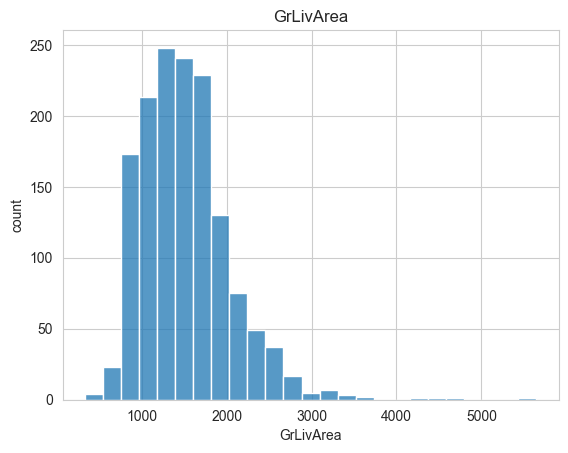

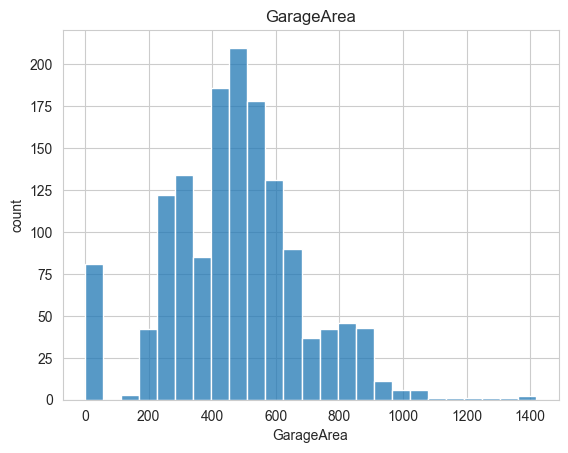

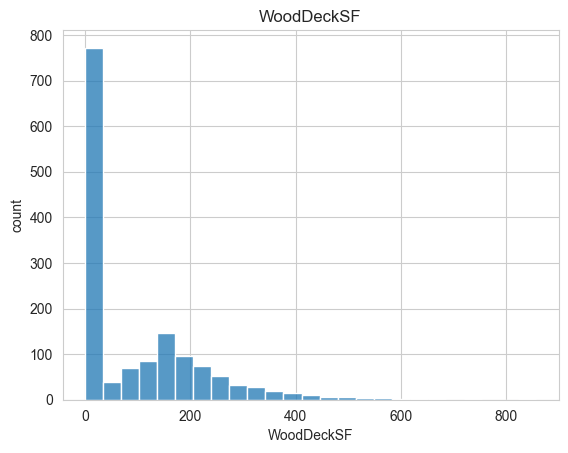

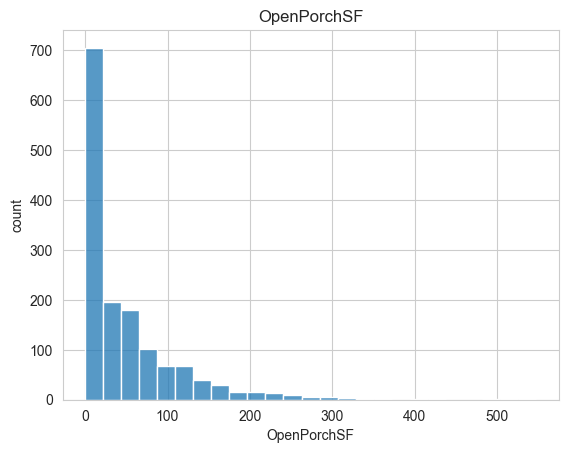

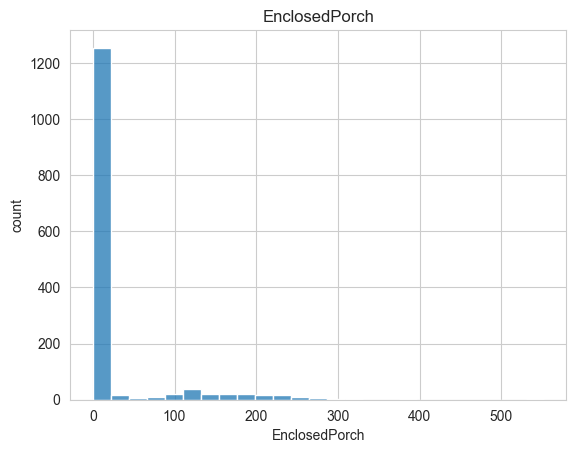

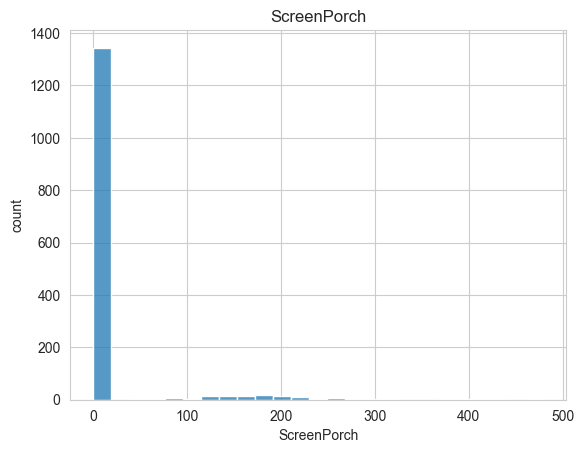

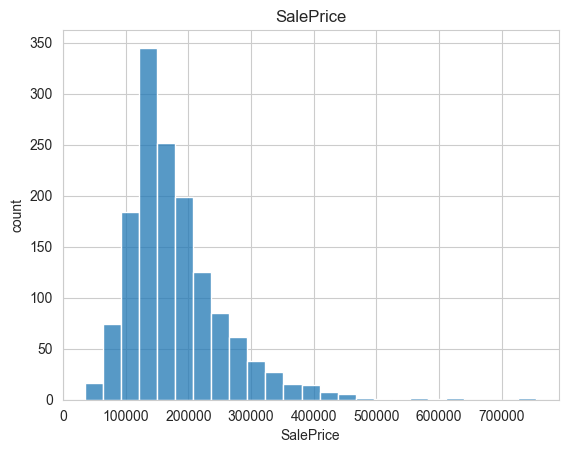

In [19]:
for feature in continuous:
    data=df.copy()
    dataset=data[feature]
    sns.histplot(dataset,bins=25)
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.title(feature)
    plt.show()

## *slightly normal distributed variables*
1. sales price
2. fistflrsf
3. totalbsmtsf


## *make it as normal distribution using method of transformation*

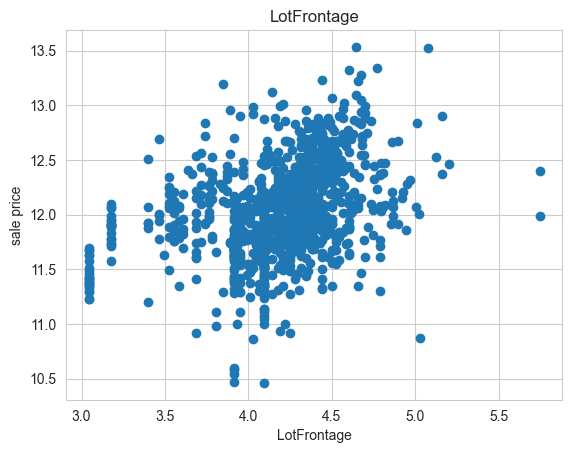

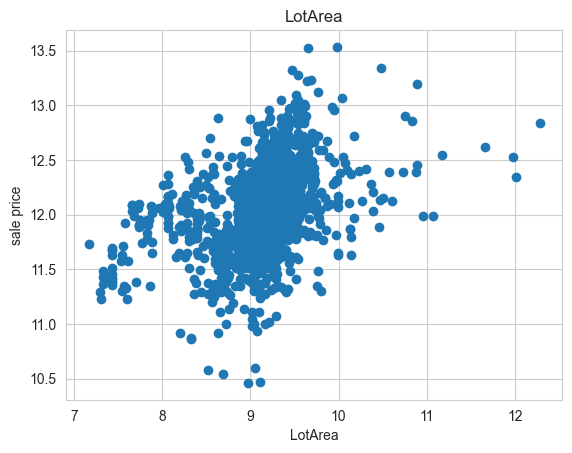

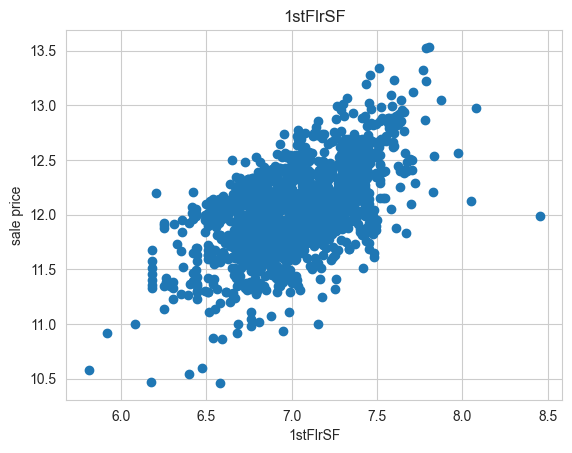

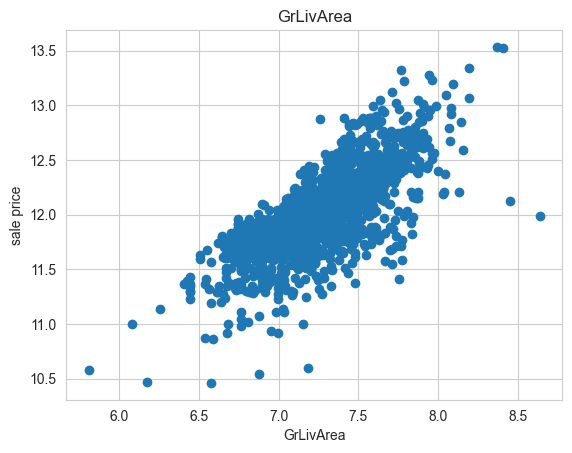

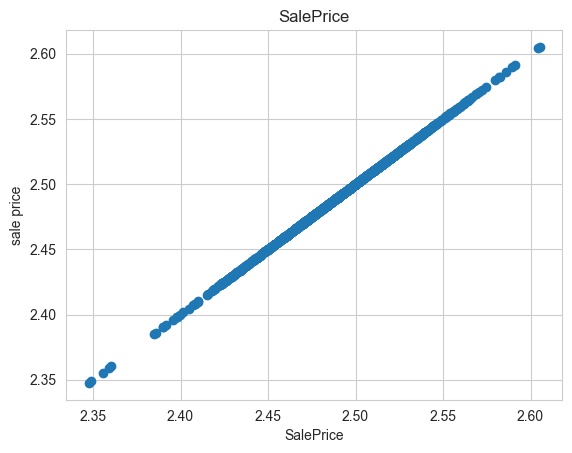

In [20]:
for feature in continuous:
    data=df.copy()
    if 0 in data[feature].unique():
        pass
    else:
        data[feature]=np.log(data[feature])
        data["SalePrice"]=np.log(data["SalePrice"])
        plt.scatter(data[feature],data["SalePrice"])
        plt.xlabel(feature)
        plt.ylabel("sale price")
        plt.title(feature)
        plt.show()
    

## *log transformation made skewed features as normal distribution*
*it is looks like increasing monotonic relation between sales price and some features*

##  **finding outliers for each features**

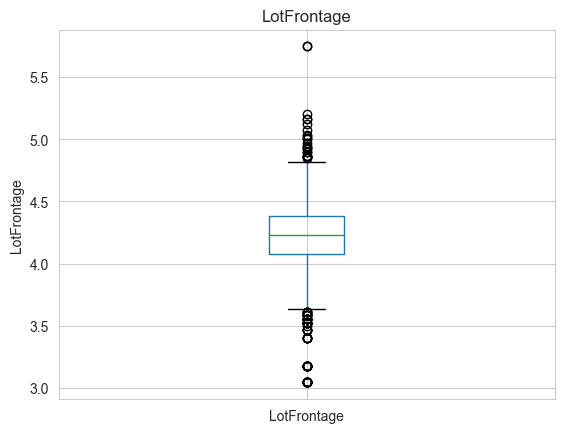

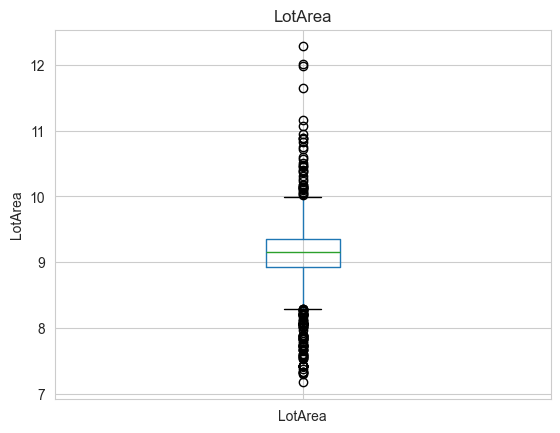

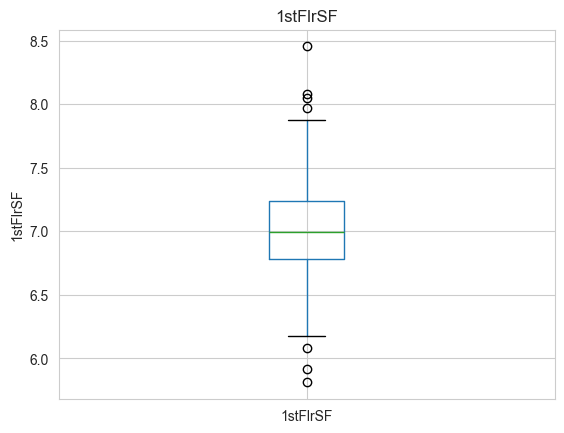

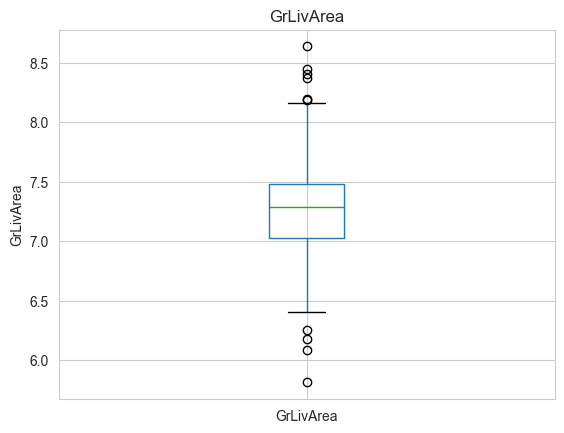

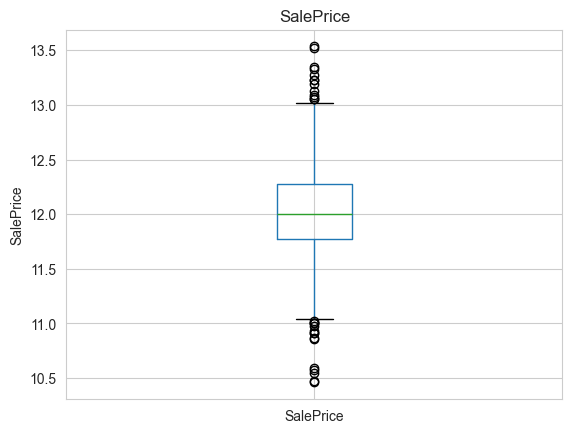

In [21]:
for feature in continuous:
    data=df.copy()
    if 0 in data[feature].unique():
        pass
    else:
        data[feature]=np.log(data[feature])
        data.boxplot(column=feature)
        plt.ylabel(feature)
        plt.title(feature)
        plt.show()

## *lot of outliers in all features*